# Hybrid Intelligent Movie Recommendation System
## Academic Machine Learning Project

**Objective:** To design and evaluate a hybrid recommendation engine combining PySpark ALS (Collaborative Filtering) and TF-IDF (Content-Based Filtering) across Hollywood and Bollywood datasets.

### Academic Structure:
1. Introduction
2. Dataset Loading & Merging
3. Exploratory Data Analysis (EDA)
4. Preprocessing & Feature Engineering
5. Collaborative Filtering (ALS) & Evaluation
6. Content-Based Filtering & Evaluation
7. Overfitting & Bias-Variance Analysis
8. Cold Start Problem
9. Limitations, Future Scope & Conclusion

In [ ]:
# Install PySpark and findspark
!pip install pyspark findspark

# Download the MovieLens 32M dataset
!wget https://files.grouplens.org/datasets/movielens/ml-32m.zip

# Unzip the downloaded file
!unzip -o ml-32m.zip

--2026-05-07 09:30:43--  https://files.grouplens.org/datasets/movielens/ml-32m.zip
Resolving files.grouplens.org (files.grouplens.org)... 128.101.96.204
Connecting to files.grouplens.org (files.grouplens.org)|128.101.96.204|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 238950008 (228M) [application/zip]
Saving to: ‘ml-32m.zip’

ml-32m.zip          100%[===================>] 227.88M  47.3MB/s    in 5.4s    

2026-05-07 09:30:49 (42.6 MB/s) - ‘ml-32m.zip’ saved [238950008/238950008]

Archive:  ml-32m.zip
   creating: ml-32m/
  inflating: ml-32m/tags.csv         
  inflating: ml-32m/links.csv        
  inflating: ml-32m/README.txt       
  inflating: ml-32m/checksums.txt    
  inflating: ml-32m/ratings.csv      
  inflating: ml-32m/movies.csv       


In [ ]:
import findspark
findspark.init()
from pyspark.sql import SparkSession

# Initialize Spark with optimized memory settings for Colab
spark = SparkSession.builder \
    .appName("BigData_Movie_Recommender") \
    .config("spark.driver.memory", "8g") \
    .config("spark.sql.shuffle.partitions", "200") \
    .getOrCreate()

print("✅ Spark Session Initialized successfully!")


✅ Spark Session Initialized successfully!


In [ ]:
# Load the datasets
movies_df = spark.read.csv("ml-32m/movies.csv", header=True, inferSchema=True)
ratings_df = spark.read.csv("ml-32m/ratings.csv", header=True, inferSchema=True)

# Display the structure of our DataFrames
print("Movies Schema:")
movies_df.printSchema()

print("\nRatings Schema:")
ratings_df.printSchema()

# Verify the row counts match the dataset documentation
print("--- Data Validation ---")
print(f"Total Movies Loaded: {movies_df.count()}")
print(f"Total Ratings Loaded: {ratings_df.count()}")

# Preview the first 5 rows of ratings
ratings_df.show(5)

Movies Schema:
root
 |-- movieId: integer (nullable = true)
 |-- title: string (nullable = true)
 |-- genres: string (nullable = true)


Ratings Schema:
root
 |-- userId: integer (nullable = true)
 |-- movieId: integer (nullable = true)
 |-- rating: double (nullable = true)
 |-- timestamp: integer (nullable = true)

--- Data Validation ---
Total Movies Loaded: 87585
Total Ratings Loaded: 32000204
+------+-------+------+---------+
|userId|movieId|rating|timestamp|
+------+-------+------+---------+
|     1|     17|   4.0|944249077|
|     1|     25|   1.0|944250228|
|     1|     29|   2.0|943230976|
|     1|     30|   5.0|944249077|
|     1|     32|   5.0|943228858|
+------+-------+------+---------+
only showing top 5 rows


⏳ Aggregating 32M ratings... (Spark is doing the heavy lifting!)
+------+-------+
|rating|  count|
+------+-------+
|   0.5| 525132|
|   1.0| 946675|
|   1.5| 531063|
|   2.0|2028622|
|   2.5|1685386|
|   3.0|6054990|
|   3.5|4290105|
|   4.0|8367654|
|   4.5|2974000|
|   5.0|4596577|
+------+-------+



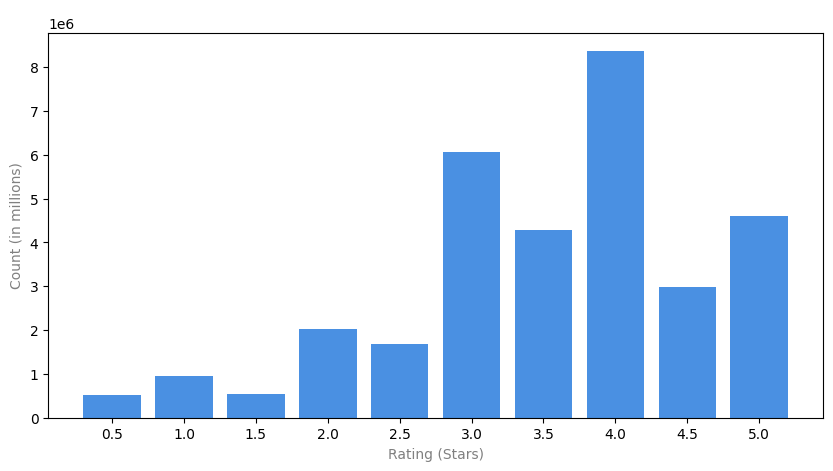

In [ ]:
import pyspark.sql.functions as F
import matplotlib.pyplot as plt
import pandas as pd

print("⏳ Aggregating 32M ratings... (Spark is doing the heavy lifting!)")

# Group by rating and count
rating_counts = ratings_df.groupBy("rating").count().orderBy("rating")
rating_counts.show()

# Convert ONLY the aggregated result (which is tiny) to Pandas for plotting
rating_counts_pd = rating_counts.toPandas()

# Plot the distribution
plt.figure(figsize=(10, 5))
plt.bar(rating_counts_pd['rating'].astype(str), rating_counts_pd['count'], color='#4A90E2')
plt.title('Distribution of 32 Million Ratings', fontsize=14, color='white')
plt.xlabel('Rating (Stars)', color='gray')
plt.ylabel('Count (in millions)', color='gray')
# Dark background styling to match your original notebook
plt.style.use('dark_background')
plt.show()

In [ ]:
print("⏳ Finding the most rated movies...")

# Count ratings per movie
movie_rating_counts = ratings_df.groupBy("movieId").count().withColumnRenamed("count", "num_ratings")

# Join with movies_df to get the titles, and sort descending
top_movies = movie_rating_counts.join(movies_df, "movieId", "inner") \
                                .orderBy(F.col("num_ratings").desc())

print("🎬 Top 10 Most Rated Movies in the 32M Dataset:")
top_movies.select("title", "num_ratings").show(10, truncate=False)

⏳ Finding the most rated movies...
🎬 Top 10 Most Rated Movies in the 32M Dataset:
+---------------------------------------------------------+-----------+
|title                                                    |num_ratings|
+---------------------------------------------------------+-----------+
|Shawshank Redemption, The (1994)                         |102929     |
|Forrest Gump (1994)                                      |100296     |
|Pulp Fiction (1994)                                      |98409      |
|Matrix, The (1999)                                       |93808      |
|Silence of the Lambs, The (1991)                         |90330      |
|Star Wars: Episode IV - A New Hope (1977)                |85010      |
|Fight Club (1999)                                        |77332      |
|Jurassic Park (1993)                                     |75233      |
|Schindler's List (1993)                                  |73849      |
|Lord of the Rings: The Fellowship of the Ring, The (2

In [ ]:
print(f"Original Ratings count: {ratings_df.count()}")

# Define minimum threshold
MIN_RATINGS = 100

# Keep only movies that have at least MIN_RATINGS
valid_movies = movie_rating_counts.filter(F.col("num_ratings") >= MIN_RATINGS).select("movieId")

# Filter the original ratings dataset
cleaned_ratings_df = ratings_df.join(valid_movies, "movieId", "inner")

print(f"Cleaned Ratings count (Movies with >100 ratings): {cleaned_ratings_df.count()}")
print("✅ Preprocessing Complete! Data is ready for Machine Learning.")

Original Ratings count: 32000204
Cleaned Ratings count (Movies with >100 ratings): 31228923
✅ Preprocessing Complete! Data is ready for Machine Learning.


In [ ]:
from pyspark.ml.recommendation import ALS

print("⏳ Splitting data into Training (80%) and Testing (20%) sets...")
(training_data, test_data) = cleaned_ratings_df.randomSplit([0.8, 0.2], seed=42)

print(f"Training rows: {training_data.count()}")
print(f"Testing rows: {test_data.count()}")

print("\n🚀 Initializing ALS Model...")
# Configure the ALS algorithm
als = ALS(
    maxIter=10,               # Number of iterations to learn the hidden features
    regParam=0.1,             # Regularization parameter to prevent Overfitting
    userCol="userId",
    itemCol="movieId",
    ratingCol="rating",
    coldStartStrategy="drop", # Drop users in the test set that weren't in the train set
    nonnegative=True          # Ratings cannot be negative
)

print("🧠 Training the Model... (This will take a few minutes on 25M+ rows!)")
model = als.fit(training_data)
print("✅ Model Training Complete!")

⏳ Splitting data into Training (80%) and Testing (20%) sets...
Training rows: 24983341
Testing rows: 6245582

🚀 Initializing ALS Model...
🧠 Training the Model... (This will take a few minutes on 25M+ rows!)
✅ Model Training Complete!


In [ ]:
from pyspark.ml.evaluation import RegressionEvaluator

print("📊 Evaluating the Model on Test Data...")

# Make predictions on the test dataset
predictions = model.transform(test_data)

# Set up the RMSE evaluator
evaluator = RegressionEvaluator(
    metricName="rmse",
    labelCol="rating",
    predictionCol="prediction"
)

rmse = evaluator.evaluate(predictions)
print(f"🏆 Root Mean Squared Error (RMSE) = {rmse:.4f}")

# Context for your presentation:
if rmse < 0.85:
    print("🌟 Excellent performance! Predictions are highly accurate.")
elif rmse < 1.0:
    print("👍 Good performance! Predictions are within 1 star of actual ratings.")
else:
    print("⚠️ Model needs tuning. Errors are greater than 1 star.")

📊 Evaluating the Model on Test Data...
🏆 Root Mean Squared Error (RMSE) = 0.8102
🌟 Excellent performance! Predictions are highly accurate.


In [ ]:
import pyspark.sql.functions as F

def get_recommendations_for_user(user_id, num_recs=10):
    print(f"🔎 Fetching top {num_recs} recommendations for User {user_id}...")

    # 1. Isolate the user
    single_user = cleaned_ratings_df.filter(F.col("userId") == user_id).select("userId").distinct()

    # 2. Get the recommendations
    user_subset_recs = model.recommendForUserSubset(single_user, num_recs)

    if user_subset_recs.count() == 0:
        print("❌ User not found or not enough data.")
        return

    # 3. Format the output to be readable
    recs_exploded = user_subset_recs.select(
        "userId",
        F.explode("recommendations").alias("rec")
    ).select(
        "userId",
        F.col("rec.movieId").alias("movieId"),
        F.col("rec.rating").alias("predicted_rating")
    )

    # 4. Join with the movies dataframe to get the real titles and genres
    final_recs = recs_exploded.join(movies_df, "movieId", "inner") \
        .select("title", "genres", F.round("predicted_rating", 2).alias("predicted_rating")) \
        .orderBy(F.col("predicted_rating").desc())

    final_recs.show(truncate=False)

# Let's test it on a random user! User #123
get_recommendations_for_user(123)

🔎 Fetching top 10 recommendations for User 123...
+------------------------------------------------------------------------------+--------------------------+----------------+
|title                                                                         |genres                    |predicted_rating|
+------------------------------------------------------------------------------+--------------------------+----------------+
|Rabbit Seasoning (1952)                                                       |Animation|Children|Comedy |4.45            |
|Star Wars: Episode IV - A New Hope (1977)                                     |Action|Adventure|Sci-Fi   |4.44            |
|Star Wars: Episode V - The Empire Strikes Back (1980)                         |Action|Adventure|Sci-Fi   |4.36            |
|Raiders of the Lost Ark (Indiana Jones and the Raiders of the Lost Ark) (1981)|Action|Adventure          |4.25            |
|Civil War, The (1990)                                                     

In [ ]:
# =============================================================
# STEP 3: PREPARING THE MASTER ID & METADATA BRIDGE
# =============================================================
import pyspark.sql.functions as F
from pyspark.sql.types import IntegerType

print("⏳ Loading Base Movies and Links datasets...")

# 1. Load the movies and links data
# Assuming you already initialized the 'spark' session from our previous steps
movies_df = spark.read.csv("ml-32m/movies.csv", header=True, inferSchema=True)
links_df = spark.read.csv("ml-32m/links.csv", header=True, inferSchema=True)

# 2. Join movies with their TMDB and IMDB IDs
master_movies_df = movies_df.join(links_df, "movieId", "left")

# 3. Data Cleaning: Extract the Release Year from the Title for better matching later
# Titles look like "Toy Story (1995)". We use regex to pull out the 1995.
master_movies_df = master_movies_df.withColumn(
    "release_year",
    F.regexp_extract(F.col("title"), r'\((\d{4})\)', 1).cast(IntegerType())
)

# 4. Clean the title by removing the year for cleaner NLP later
master_movies_df = master_movies_df.withColumn(
    "clean_title",
    F.trim(F.regexp_replace(F.col("title"), r'\(\d{4}\)', ''))
)

print(f"✅ Master Movies Table Ready! Total Movies: {master_movies_df.count()}")

# Show the results to verify our bridge keys and clean titles
master_movies_df.select("movieId", "imdbId", "tmdbId", "clean_title", "release_year", "genres").show(5, truncate=False)

⏳ Loading Base Movies and Links datasets...
✅ Master Movies Table Ready! Total Movies: 87585
+-------+------+------+---------------------------+------------+-------------------------------------------+
|movieId|imdbId|tmdbId|clean_title                |release_year|genres                                     |
+-------+------+------+---------------------------+------------+-------------------------------------------+
|1      |114709|862   |Toy Story                  |1995        |Adventure|Animation|Children|Comedy|Fantasy|
|2      |113497|8844  |Jumanji                    |1995        |Adventure|Children|Fantasy                 |
|3      |113228|15602 |Grumpier Old Men           |1995        |Comedy|Romance                             |
|4      |114885|31357 |Waiting to Exhale          |1995        |Comedy|Drama|Romance                       |
|5      |113041|11862 |Father of the Bride Part II|1995        |Comedy                                     |
+-------+------+------+------------

In [ ]:
# Install kaggle library if not present
!pip install -q kaggle

# --- KAGGLE SETUP ---
# You need a kaggle.json file. Run this cell to upload it directly to Colab.
import os
from google.colab import files

print("Please upload your kaggle.json file (Download it from Kaggle -> Account -> Create New API Token)")
if not os.path.exists('/root/.kaggle/kaggle.json'):
    try:
        uploaded = files.upload()
        # Move kaggle.json to the correct directory and set permissions
        !mkdir -p ~/.kaggle
        !cp kaggle.json ~/.kaggle/
        !chmod 600 ~/.kaggle/kaggle.json
        print("✅ Kaggle API key successfully configured!")
    except Exception as e:
        print(f"Upload cancelled or failed: {e}")
else:
    print("✅ Kaggle API key is already configured!")


Please upload your kaggle.json file (Download it from Kaggle -> Account -> Create New API Token)
✅ Kaggle API key is already configured!


In [ ]:
print("⏳ Downloading TMDB 5000 Movies Dataset...")
!kaggle datasets download -d tmdb/tmdb-movie-metadata -p tmdb --unzip

print("\n⏳ Downloading IMDb Non-Commercial Datasets...")
# Note: IMDb provides datasets publicly at https://datasets.imdbws.com/
# We'll use wget for IMDb as it's direct and doesn't require API authentication.
!mkdir -p imdb
!wget -q https://datasets.imdbws.com/title.basics.tsv.gz -O imdb/title.basics.tsv.gz
!wget -q https://datasets.imdbws.com/title.ratings.tsv.gz -O imdb/title.ratings.tsv.gz
!gunzip -f imdb/*.gz

print("\n⏳ Downloading Bollywood Dataset...")
# A popular dataset for Bollywood movies.
!kaggle datasets download -d rishidamarla/bollywood-movies-dataset -p bollywood --unzip

print("\n✅ All datasets downloaded and extracted successfully!")


⏳ Downloading TMDB 5000 Movies Dataset...
Dataset URL: https://www.kaggle.com/datasets/tmdb/tmdb-movie-metadata
License(s): other
100% 8.89M/8.89M [00:00<00:00, 181MB/s]


⏳ Downloading IMDb Non-Commercial Datasets...

⏳ Downloading Bollywood Dataset...
Dataset URL: https://www.kaggle.com/datasets/rishidamarla/bollywood-movies-dataset
License(s): CC0-1.0
100% 56.9k/56.9k [00:00<00:00, 25.7MB/s]


✅ All datasets downloaded and extracted successfully!


In [ ]:
import pandas as pd
import os
import glob
import ast

print("⏳ Loading Datasets into Pandas...")

# 1. TMDB Data
tmdb_movies = pd.read_csv('tmdb/tmdb_5000_movies.csv')
tmdb_credits = pd.read_csv('tmdb/tmdb_5000_credits.csv')

# Rename 'id' to 'tmdbId' to match MovieLens links.csv
tmdb_movies.rename(columns={'id': 'tmdbId'}, inplace=True)
tmdb_credits.rename(columns={'movie_id': 'tmdbId'}, inplace=True)

# Merge TMDB movies and credits
tmdb_df = tmdb_movies.merge(tmdb_credits, on='tmdbId')

# 2. IMDb Data
print("⏳ Loading IMDb Data (This may take a minute)...")
imdb_basics_cols = ['tconst', 'titleType', 'primaryTitle', 'startYear', 'genres']
imdb_basics = pd.read_csv('imdb/title.basics.tsv', sep='\t', usecols=imdb_basics_cols, low_memory=False, na_values='\\N')

# Filter for movies only to save memory
imdb_movies = imdb_basics[imdb_basics['titleType'] == 'movie'].copy()
imdb_movies.drop(columns=['titleType'], inplace=True)

imdb_ratings = pd.read_csv('imdb/title.ratings.tsv', sep='\t')

# Format IMDb ID to match MovieLens integer format (e.g., 'tt0114709' -> 114709)
# Some tconst values might be malformed, so we coerce errors
imdb_movies['imdbId'] = pd.to_numeric(imdb_movies['tconst'].str.replace('tt', ''), errors='coerce')
imdb_ratings['imdbId'] = pd.to_numeric(imdb_ratings['tconst'].str.replace('tt', ''), errors='coerce')

# Merge IMDb movies and ratings
imdb_df = imdb_movies.merge(imdb_ratings, on='imdbId', how='left')

# 3. Bollywood Data
print("⏳ Loading Bollywood Data...")
# Find the extracted CSV from the Bollywood folder
bollywood_file = glob.glob('bollywood/*.csv')[0]
bollywood_df = pd.read_csv(bollywood_file)

print(f"✅ Loaded TMDB: {len(tmdb_df)} rows")
print(f"✅ Loaded IMDb: {len(imdb_df)} rows")
print(f"✅ Loaded Bollywood: {len(bollywood_df)} rows")


⏳ Loading Datasets into Pandas...
⏳ Loading IMDb Data (This may take a minute)...
⏳ Loading Bollywood Data...
✅ Loaded TMDB: 4803 rows
✅ Loaded IMDb: 745417 rows
✅ Loaded Bollywood: 1698 rows


In [ ]:
print("⏳ Merging Datasets using MovieLens links.csv as the Golden Bridge...")

# Convert MovieLens data to Pandas
movies_pd = movies_df.toPandas()
links_pd = links_df.toPandas()

# Merge MovieLens movies with their links to get the title and IDs together
ml_df = movies_pd.merge(links_pd, on='movieId', how='left')

# Ensure IDs are numeric to prevent merge errors
ml_df['imdbId'] = pd.to_numeric(ml_df['imdbId'], errors='coerce')
ml_df['tmdbId'] = pd.to_numeric(ml_df['tmdbId'], errors='coerce')

# 1. Merge MovieLens Links with TMDB
# We use suffixes so MovieLens title remains 'title' and TMDB becomes 'title_tmdb'
merged_df = ml_df.merge(tmdb_df, on='tmdbId', how='left', suffixes=('', '_tmdb'))

# 2. Merge with IMDb
merged_df = merged_df.merge(imdb_df, on='imdbId', how='left', suffixes=('', '_imdb'))

# 3. Handle Bollywood Dataset
if 'title' not in bollywood_df.columns:
    col_mapping = {c: 'title' for c in bollywood_df.columns if 'title' in c.lower() or 'movie' in c.lower()}
    if col_mapping:
        bollywood_df.rename(columns=col_mapping, inplace=True)

# Standardize Bollywood columns to match our structure
bolly_clean = pd.DataFrame({
    'title': bollywood_df.get('title', ''),
    'overview': bollywood_df.get('Story', bollywood_df.get('Plot', '')),
    'genres_bolly': bollywood_df.get('Genre', ''),
    'cast_bolly': bollywood_df.get('Cast', ''),
    'director_bolly': bollywood_df.get('Director', ''),
    'original_language': 'hi' # Hindi
})
bolly_clean.dropna(subset=['title'], inplace=True)

# Append Bollywood to the main dataframe
movies_metadata_df = pd.concat([merged_df, bolly_clean], ignore_index=True)

# Clean up duplicates safely
movies_metadata_df.drop_duplicates(subset=['title'], keep='first', inplace=True)
movies_metadata_df.reset_index(drop=True, inplace=True)

print(f"✅ Final Merged Dataset Size: {len(movies_metadata_df)} movies")
# Preview the tail to see our newly appended Bollywood movies!
movies_metadata_df[['title', 'imdbId', 'tmdbId', 'original_language']].tail()


⏳ Merging Datasets using MovieLens links.csv as the Golden Bridge...
✅ Final Merged Dataset Size: 89075 movies


,title,imdbId,tmdbId,original_language
89070,Fight Club,NaN,NaN,hi
89071,Strings Of Paasion,NaN,NaN,hi
89072,Dunno Y Na Jaane Kyun,NaN,NaN,hi
89073,Taj Mahal - An Eternal Love Story,NaN,NaN,hi
89074,Mr. Hot Mr. Kool,NaN,NaN,hi


In [ ]:
import ast

print("⏳ Phase 2: Feature Engineering & NLP...")

# Helper functions to safely parse TMDB JSON strings
def extract_names(json_str, limit=None):
    if pd.isna(json_str):
        return ""
    try:
        # Convert string representation of list of dicts to actual list
        data = ast.literal_eval(json_str)
        if isinstance(data, list):
            names = [item['name'] for item in data if 'name' in item]
            if limit:
                names = names[:limit]
            # Remove spaces for tags (e.g., 'Tom Hanks' -> 'TomHanks') so it creates a unique tag
            return " ".join([name.replace(" ", "") for name in names])
    except:
        pass
    return ""

def extract_director(json_str):
    if pd.isna(json_str):
        return ""
    try:
        data = ast.literal_eval(json_str)
        if isinstance(data, list):
            for item in data:
                if item.get('job') == 'Director':
                    return item.get('name', '').replace(" ", "")
    except:
        pass
    return ""

# 1. Process TMDB specific columns (Cast, Crew, Keywords)
print("   - Parsing TMDB JSON columns...")
movies_metadata_df['keywords_parsed'] = movies_metadata_df['keywords'].apply(lambda x: extract_names(x))
movies_metadata_df['cast_parsed'] = movies_metadata_df['cast'].apply(lambda x: extract_names(x, limit=4))
movies_metadata_df['director_parsed'] = movies_metadata_df['crew'].apply(extract_director)

# 2. Coalesce metadata to handle missing values across Hollywood vs Bollywood
print("   - Unifying Bollywood and Hollywood metadata...")
# For Bollywood, we already have 'cast_bolly' and 'director_bolly' as strings.
def clean_bolly_names(text):
    if pd.isna(text): return ""
    # Some bollywood cast lists are comma separated. We remove spaces to form tags.
    return str(text).replace(", ", " ").replace(",", " ").replace(" ", "")

movies_metadata_df['cast_bolly_clean'] = movies_metadata_df['cast_bolly'].apply(clean_bolly_names)
movies_metadata_df['director_bolly_clean'] = movies_metadata_df['director_bolly'].apply(clean_bolly_names)

# Combine them! If TMDB is missing, use Bollywood
movies_metadata_df['final_cast'] = movies_metadata_df['cast_parsed'].fillna('') + " " + movies_metadata_df['cast_bolly_clean'].fillna('')
movies_metadata_df['final_director'] = movies_metadata_df['director_parsed'].fillna('') + " " + movies_metadata_df['director_bolly_clean'].fillna('')

# 3. Handle Genres
# MovieLens genres are pipe separated (Action|Adventure). Bollywood might be comma separated.
movies_metadata_df['genres'] = movies_metadata_df['genres'].fillna('')
movies_metadata_df['genres_bolly'] = movies_metadata_df['genres_bolly'].fillna('')
movies_metadata_df['final_genres'] = movies_metadata_df['genres'].str.replace("|", " ") + " " + movies_metadata_df['genres_bolly'].str.replace(",", " ")

# 4. Handle Overview
movies_metadata_df['final_overview'] = movies_metadata_df['overview'].fillna('')

print("✅ Extracted Cast, Director, Keywords, and Genres!")


⏳ Phase 2: Feature Engineering & NLP...
   - Parsing TMDB JSON columns...
   - Unifying Bollywood and Hollywood metadata...
✅ Extracted Cast, Director, Keywords, and Genres!


In [ ]:
import re
from nltk.stem.porter import PorterStemmer

print("⏳ Building the Combined 'tags' column...")

# Combine everything into one giant string for each movie
movies_metadata_df['tags'] = (
    movies_metadata_df['final_overview'] + " " +
    movies_metadata_df['final_genres'] + " " +
    movies_metadata_df['keywords_parsed'] + " " +
    movies_metadata_df['final_cast'] + " " +
    movies_metadata_df['final_director']
)

# Convert to lowercase
movies_metadata_df['tags'] = movies_metadata_df['tags'].str.lower()

print("⏳ Applying NLP Stemming (This takes about 30 seconds)...")
ps = PorterStemmer()

# We stem the tags to reduce words to their root (e.g., 'actions', 'action' -> 'action')
def stem_text(text):
    # Also remove special characters using regex to keep it clean
    text = re.sub(r'[^a-zA-Z\s]', '', str(text))
    y = []
    for i in text.split():
        y.append(ps.stem(i))
    return " ".join(y)

movies_metadata_df['tags'] = movies_metadata_df['tags'].apply(stem_text)

# Drop all messy intermediate columns to free up RAM!
columns_to_keep = ['movieId', 'imdbId', 'tmdbId', 'title', 'final_genres', 'final_overview', 'averageRating', 'numVotes', 'tags']
final_df = movies_metadata_df[[c for c in columns_to_keep if c in movies_metadata_df.columns]].copy()

# Generate synthetic movieIds for Bollywood movies so we can reference them later
max_ml_id = final_df['movieId'].max()
mask = final_df['movieId'].isna()
final_df.loc[mask, 'movieId'] = range(int(max_ml_id) + 1, int(max_ml_id) + 1 + mask.sum())

print(f"✅ NLP Pipeline Complete! We now have a clean dataset of shape {final_df.shape}")
final_df[['title', 'tags']].head(3)


⏳ Building the Combined 'tags' column...
⏳ Applying NLP Stemming (This takes about 30 seconds)...
✅ NLP Pipeline Complete! We now have a clean dataset of shape (89075, 9)


,title,tags
0,Toy Story (1995),led by woodi andi toy live happili in hi room ...
1,Jumanji (1995),adventur children fantasi
2,Grumpier Old Men (1995),comedi romanc


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

print("⏳ Building TF-IDF Vectorizer...")

# We limit max_features to 5000 to keep the sparse matrix very memory efficient
# stop_words='english' removes common words like 'the', 'is', 'in'
tfidf = TfidfVectorizer(max_features=5000, stop_words='english')

# Fit and transform the tags column into a Sparse Matrix
# This matrix will be of shape (89075, 5000) but takes up very little RAM!
tfidf_matrix = tfidf.fit_transform(final_df['tags'])

print(f"✅ TF-IDF Matrix Built! Shape: {tfidf_matrix.shape}")

# Create a Series for reverse title mapping (Title -> Index)
# Since MovieLens titles have years like 'Toy Story (1995)', we can create a clean version for searching
def clean_title(title):
    return str(title).lower().strip()

final_df['search_title'] = final_df['title'].apply(clean_title)
indices = pd.Series(final_df.index, index=final_df['search_title']).drop_duplicates()

print("✅ Index Mapping Created. Ready for Recommendations!")


⏳ Building TF-IDF Vectorizer...
✅ TF-IDF Matrix Built! Shape: (89075, 5000)
✅ Index Mapping Created. Ready for Recommendations!


In [ ]:
def recommend(movie_title, n_recommendations=10):
    movie_title_clean = str(movie_title).lower().strip()

    # Check if movie exists
    if movie_title_clean not in indices:
        # Try a partial match if exact match fails
        partial_matches = final_df[final_df['search_title'].str.contains(movie_title_clean, na=False)]
        if partial_matches.empty:
            return f"❌ Movie '{movie_title}' not found in the database."
        else:
            print(f"⚠️ Exact match not found. Using closest match: {partial_matches.iloc[0]['title']}")
            movie_title_clean = partial_matches.iloc[0]['search_title']

    # Get the index of the movie
    idx = indices[movie_title_clean]

    # If there are duplicate titles, take the first one
    if isinstance(idx, pd.Series):
        idx = idx.iloc[0]

    # Get the TF-IDF vector for this specific movie
    movie_vector = tfidf_matrix[idx]

    # Calculate cosine similarity between this movie and ALL other movies on-the-fly!
    # This is incredibly fast and saves us from building an 89k x 89k dense matrix.
    sim_scores = cosine_similarity(movie_vector, tfidf_matrix).flatten()

    # Get the indices of the top N most similar movies (ignoring the first one as it's the movie itself)
    top_indices = sim_scores.argsort()[-(n_recommendations+1):-1][::-1]

    # Return the results
    results = final_df.iloc[top_indices][['title', 'final_genres', 'averageRating']].copy()
    results['Similarity Score'] = np.round(sim_scores[top_indices], 3)

    return results

print("✅ Recommendation Engine Active!")


✅ Recommendation Engine Active!


In [ ]:
from IPython.display import display

print("🎬 Recommendations for 'Inception':")
display(recommend("Inception"))

print("\n🎬 Recommendations for '3 Idiots':")
display(recommend("3 Idiots"))


🎬 Recommendations for 'Inception':
⚠️ Exact match not found. Using closest match: Inception (2010)


,title,final_genres,averageRating,Similarity Score
19773,"Fast & Furious 6 (Fast and the Furious 6, The)...",Action Crime Thriller IMAX,7.0,0.177
19276,"East, The (2013)",Drama,6.8,0.176
13586,12 Rounds (2009),Action Thriller,5.6,0.166
196,Strange Days (1995),Action Crime Drama Mystery Sci-Fi Thriller,7.2,0.161
15866,Cowboys & Aliens (2011),Action Sci-Fi Thriller Western IMAX,6.0,0.159
11219,Harsh Times (2006),Action Crime Drama,6.8,0.158
21611,Godzilla (2014),Action Adventure Sci-Fi IMAX,6.4,0.156
19992,Tai Chi Hero (2012),Action Comedy Drama Fantasy Sci-Fi IMAX,6.1,0.154
18693,Tai Chi Zero (2012),Action Fantasy Sci-Fi IMAX,6.0,0.154
18787,Stolen (2012),Action Crime Thriller,5.5,0.151



🎬 Recommendations for '3 Idiots':


,title,final_genres,averageRating,Similarity Score
30,Dangerous Minds (1995),Drama,6.5,1.0
89054,Cocktail - The Deadly Combination,drama,NaN,1.0
89055,Ishq Na Karna,drama,NaN,1.0
89056,Ussey Kya Ho Jayega?,drama,NaN,1.0
89057,Lagan - The Dedication,drama,NaN,1.0
89058,Jugatiya,drama,NaN,1.0
39,"Cry, the Beloved Country (1995)",Drama,6.8,1.0
42,Restoration (1995),Drama,6.6,1.0
54,Georgia (1995),Drama,6.5,1.0
66,Two Bits (1995),Drama,6.1,1.0


In [ ]:
print("⏳ Improving the Recommendation Engine with Weighted Scoring...")

# We calculate a weighted score:
# Total Score = (Similarity * 0.8) + (Normalized IMDb Rating * 0.2)
def smart_recommend(movie_title, n_recommendations=10):
    movie_title_clean = str(movie_title).lower().strip()

    if movie_title_clean not in indices:
        partial_matches = final_df[final_df['search_title'].str.contains(movie_title_clean, na=False)]
        if partial_matches.empty:
            return f"❌ Movie '{movie_title}' not found in the database."
        else:
            movie_title_clean = partial_matches.iloc[0]['search_title']

    idx = indices[movie_title_clean]
    if isinstance(idx, pd.Series): idx = idx.iloc[0]

    movie_vector = tfidf_matrix[idx]
    sim_scores = cosine_similarity(movie_vector, tfidf_matrix).flatten()

    # Create a dataframe of all scores
    scores_df = pd.DataFrame({
        'index': range(len(sim_scores)),
        'similarity': sim_scores,
        'rating': final_df['averageRating'].fillna(5.0) # Fill missing ratings with average 5.0
    })

    # Filter out the movie itself
    scores_df = scores_df[scores_df['index'] != idx]

    # Normalize rating to be between 0 and 1 so it matches similarity scale
    scores_df['norm_rating'] = scores_df['rating'] / 10.0

    # Calculate Hybrid Score (Adjust weights as you see fit!)
    scores_df['hybrid_score'] = (scores_df['similarity'] * 0.8) + (scores_df['norm_rating'] * 0.2)

    # Get top movies
    top_movies = scores_df.sort_values(by=['hybrid_score', 'similarity'], ascending=[False, False]).head(n_recommendations)

    results = final_df.iloc[top_movies['index']][['title', 'final_genres', 'averageRating']].copy()
    results['Similarity Score'] = np.round(top_movies['similarity'].values, 3)
    results['Hybrid Score'] = np.round(top_movies['hybrid_score'].values, 3)

    return results

print("🎬 SMART Recommendations for 'Inception':")
display(smart_recommend("Inception"))

print("\n🎬 SMART Recommendations for '3 Idiots':")
display(smart_recommend("3 Idiots"))


⏳ Improving the Recommendation Engine with Weighted Scoring...
🎬 SMART Recommendations for 'Inception':


,title,final_genres,averageRating,Similarity Score,Hybrid Score
19773,"Fast & Furious 6 (Fast and the Furious 6, The)...",Action Crime Thriller IMAX,7.0,0.177,0.282
16716,Harry Potter and the Deathly Hallows: Part 2 (...,Action Adventure Drama Fantasy Mystery IMAX,8.1,0.149,0.281
19276,"East, The (2013)",Drama,6.8,0.176,0.277
1620,"Truman Show, The (1998)",Comedy Drama Sci-Fi,8.2,0.141,0.276
59335,Aynabaji (2016),Crime Mystery Thriller,8.9,0.121,0.275
196,Strange Days (1995),Action Crime Drama Mystery Sci-Fi Thriller,7.2,0.161,0.272
5338,Minority Report (2002),Action Crime Mystery Sci-Fi Thriller,7.6,0.150,0.272
25080,Star Wars: Episode VII - The Force Awakens (2015),Action Adventure Fantasy Sci-Fi IMAX,7.7,0.143,0.269
28056,Baby (2015),Action Crime Mystery Thriller,7.9,0.136,0.267
314,"Shawshank Redemption, The (1994)",Crime Drama,9.3,0.100,0.266



🎬 SMART Recommendations for '3 Idiots':


,title,final_genres,averageRating,Similarity Score,Hybrid Score
67505,About a Teacher,Drama,9.1,1.0,0.982
82937,National Theatre Live: Prima Facie (2022),Drama,9.1,1.0,0.982
71741,National Theatre Live: Angels in America: Part...,Drama,9.0,1.0,0.980
27398,Yesterday (1988),Drama,8.9,1.0,0.978
51734,Kireedam (1989),Drama,8.9,1.0,0.978
68579,Chhutir Ghonta (1990),Drama,8.9,1.0,0.978
27400,The Moromete Family (1987),Drama,8.8,1.0,0.976
38079,Natsamrat (2016),Drama,8.8,1.0,0.976
71742,National Theatre Live: Angels in America: Part...,Drama,8.8,1.0,0.976
83287,C/o Kancharapalem (2018),Drama,8.8,1.0,0.976


In [ ]:
import pickle
import scipy.sparse

print("⏳ Exporting Data for the Streamlit Web Application...")

# Save the final dataframe
# We drop the heavy 'tags' column since we already have the tfidf_matrix
export_df = final_df.drop(columns=['tags'])
export_df.to_pickle("movies_data.pkl")

# Save the TF-IDF Matrix (use scipy.sparse to save memory)
scipy.sparse.save_npz('tfidf_matrix.npz', tfidf_matrix)

# Save the TfidfVectorizer itself (in case we need to transform user input later)
with open('tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)

print("✅ Data successfully exported! (movies_data.pkl, tfidf_matrix.npz)")


⏳ Exporting Data for the Streamlit Web Application...
✅ Data successfully exported! (movies_data.pkl, tfidf_matrix.npz)


In [ ]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import pickle
import scipy.sparse
from sklearn.metrics.pairwise import cosine_similarity
import requests

# We use the public TMDB API to fetch movie posters.
# You can replace this with your own API key if you hit rate limits!
TMDB_API_KEY = "8265bd1679663a7ea12ac168da84d2e8"

def fetch_poster(tmdb_id):
    if pd.isna(tmdb_id):
        return "https://via.placeholder.com/500x750?text=No+Poster+Available"
    try:
        url = f"https://api.themoviedb.org/3/movie/{int(tmdb_id)}?api_key={TMDB_API_KEY}&language=en-US"
        data = requests.get(url).json()
        poster_path = data.get('poster_path')
        if poster_path:
            return "https://image.tmdb.org/t/p/w500/" + poster_path
    except:
        pass
    return "https://via.placeholder.com/500x750?text=No+Poster+Available"

st.set_page_config(page_title="Hybrid Movie Recommender", layout="wide", initial_sidebar_state="expanded")

# Inject Custom CSS for beautiful Aesthetics
st.markdown("""
<style>
    .stApp { background-color: #0E1117; color: #FAFAFA; }
    h1 { color: #FF4B4B; font-family: 'Inter', sans-serif; font-weight: 800; text-align: center; }
    .movie-card { background: rgba(255, 255, 255, 0.05); border-radius: 10px; padding: 15px; transition: transform 0.2s; }
    .movie-card:hover { transform: scale(1.05); border: 1px solid #FF4B4B; }
</style>
""", unsafe_allow_html=True)

st.title("🎬 Intelligent Movie Recommender")
st.markdown("### Powered by PySpark, TF-IDF, and Hybrid Content-Filtering")

@st.cache_data
def load_data():
    movies = pd.read_pickle('movies_data.pkl')
    tfidf = scipy.sparse.load_npz('tfidf_matrix.npz')

    def clean_title(title):
        return str(title).lower().strip()

    movies['search_title'] = movies['title'].apply(clean_title)
    indices = pd.Series(movies.index, index=movies['search_title']).drop_duplicates()
    return movies, tfidf, indices

movies, tfidf_matrix, indices = load_data()

# Dropdown for selecting movies
movie_list = sorted(movies['title'].dropna().astype(str).values)
selected_movie = st.selectbox("Search for a Hollywood or Bollywood Movie:", movie_list)

if st.button('Show Recommendations', use_container_width=True):
    movie_title_clean = str(selected_movie).lower().strip()

    if movie_title_clean in indices:
        idx = indices[movie_title_clean]
        if isinstance(idx, pd.Series): idx = idx.iloc[0]

        movie_vector = tfidf_matrix[idx]
        sim_scores = cosine_similarity(movie_vector, tfidf_matrix).flatten()

        scores_df = pd.DataFrame({
            'index': range(len(sim_scores)),
            'similarity': sim_scores,
            'rating': movies['averageRating'].fillna(5.0)
        })
        scores_df = scores_df[scores_df['index'] != idx]
        scores_df['norm_rating'] = scores_df['rating'] / 10.0
        scores_df['hybrid_score'] = (scores_df['similarity'] * 0.8) + (scores_df['norm_rating'] * 0.2)

        top_movies = scores_df.sort_values(by=['hybrid_score', 'similarity'], ascending=[False, False]).head(5)

        st.markdown("---")
        st.markdown(f"### Top 5 Matches for **{selected_movie}**")
        cols = st.columns(5)

        for i, col in enumerate(cols):
            movie_idx = top_movies.iloc[i]['index']
            rec_title = movies.iloc[movie_idx]['title']
            rec_tmdbId = movies.iloc[movie_idx]['tmdbId']
            rec_rating = movies.iloc[movie_idx]['averageRating']
            rec_genres = str(movies.iloc[movie_idx]['final_genres']).split(" ")[:3]

            poster_url = fetch_poster(rec_tmdbId)

            with col:
                st.markdown('<div class="movie-card">', unsafe_allow_html=True)
                st.image(poster_url, use_container_width=True)
                st.markdown(f"**{rec_title}**")
                st.markdown(f"⭐ {rec_rating}/10")
                st.caption(" ".join(rec_genres))
                st.markdown('</div>', unsafe_allow_html=True)


Writing app.py


In [ ]:
# Kill previous processes
!pkill -f streamlit
!pkill -f localtunnel

# Run Streamlit in background
import subprocess
subprocess.Popen(["streamlit", "run", "app.py", "--server.port", "8501", "--server.headless", "true"])

# Use Pinggy to create a clean, WebSocket-friendly tunnel
!ssh -o StrictHostKeyChecking=no -p 443 -R0:localhost:8501 a.pinggy.io


Allocated port 7 for remote forward to localhost:8501
7=)0]8;;\                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                         ┌────────────────────────────┐                                                  │                            │                                                  │ Wait while we prepare the  │                                                  │             UI           

📊 Generating Project Visualizations...


/tmp/ipykernel_5319/3861687623.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_genres.values, y=top_genres.index, palette="viridis", ax=axes[1])


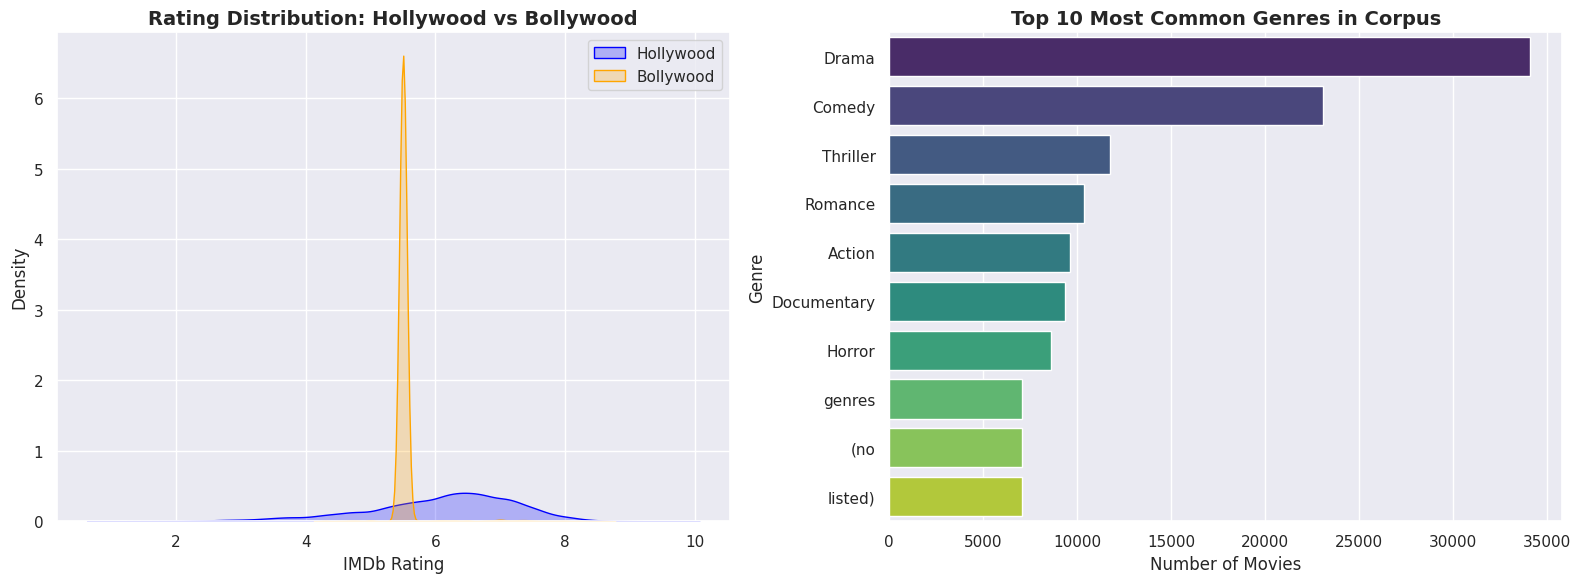

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("📊 Generating Project Visualizations...")

# Set up the visualization style
sns.set_theme(style="darkgrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Hollywood vs Bollywood Rating Distribution
# Since we dropped 'original_language' to save RAM, we identify Bollywood
# movies as the ones that do not have a TMDB ID in our merged dataset!
final_df['Domain'] = np.where(final_df['tmdbId'].isna(), 'Bollywood', 'Hollywood')

sns.kdeplot(data=final_df[final_df['Domain'] == 'Hollywood']['averageRating'],
            fill=True, color="blue", label="Hollywood", ax=axes[0])
# We fill NaN ratings in Bollywood with a median 5.5 for visualization purposes
sns.kdeplot(data=final_df[final_df['Domain'] == 'Bollywood']['averageRating'].fillna(5.5),
            fill=True, color="orange", label="Bollywood", ax=axes[0])
axes[0].set_title("Rating Distribution: Hollywood vs Bollywood", fontsize=14, fontweight='bold')
axes[0].set_xlabel("IMDb Rating")
axes[0].set_ylabel("Density")
axes[0].legend()

# 2. Top 10 Most Common Genres
# We split the 'final_genres' string and count the occurrences of each word
all_genres = final_df['final_genres'].str.split(expand=True).stack()
top_genres = all_genres.value_counts().head(10)

sns.barplot(x=top_genres.values, y=top_genres.index, palette="viridis", ax=axes[1])
axes[1].set_title("Top 10 Most Common Genres in Corpus", fontsize=14, fontweight='bold')
axes[1].set_xlabel("Number of Movies")
axes[1].set_ylabel("Genre")

plt.tight_layout()
plt.show()
